In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [5]:
df = pd.read_csv("loan_data.csv")

df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [6]:
print(df.shape)

df.info()

(614, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [7]:
df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [9]:
df["Gender"] = df["Gender"].fillna(df["Gender"].mode()[0])

df["Married"] = df["Married"].fillna(df["Married"].mode()[0])

df["Dependents"] = df["Dependents"].fillna(df["Dependents"].mode()[0])

df["Self_Employed"] = df["Self_Employed"].fillna(df["Self_Employed"].mode()[0])

df["LoanAmount"] = df["LoanAmount"].fillna(df["LoanAmount"].median())

df["Loan_Amount_Term"] = df["Loan_Amount_Term"].fillna(
    df["Loan_Amount_Term"].mode()[0]
)

df["Credit_History"] = df["Credit_History"].fillna(
    df["Credit_History"].mode()[0]
)

In [10]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

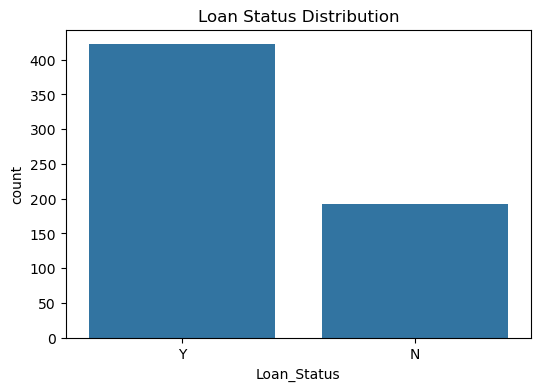

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Loan_Status",
    data=df
)

plt.title("Loan Status Distribution")

plt.show()

### Observation

The dataset contains more approved loans than rejected loans, indicating a slight class imbalance. This suggests that most applicants in the dataset were eligible for loan approval.

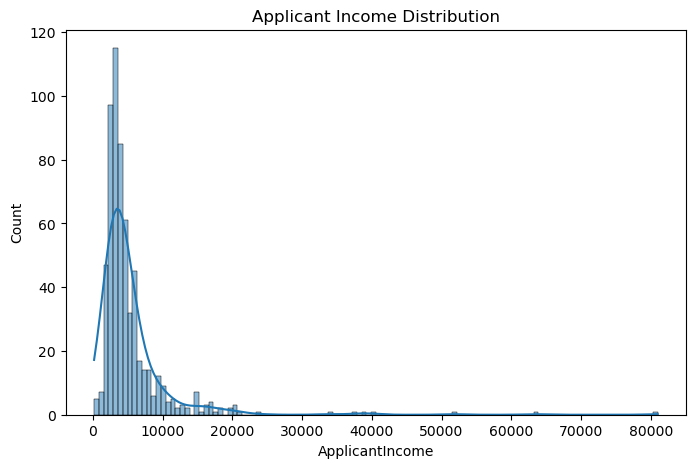

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["ApplicantIncome"],
    kde=True
)

plt.title("Applicant Income Distribution")

plt.show()

### Observation

Most applicants belong to lower and middle-income groups. A small number of applicants have significantly higher incomes, creating a right-skewed distribution.

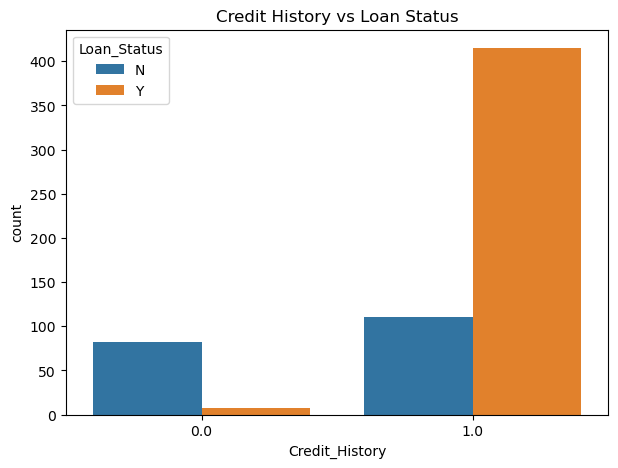

In [13]:
plt.figure(figsize=(7,5))

sns.countplot(
    x="Credit_History",
    hue="Loan_Status",
    data=df
)

plt.title("Credit History vs Loan Status")

plt.show()

### Observation

Applicants with a positive credit history have a much higher probability of loan approval. Credit history appears to be one of the most important factors influencing lending decisions.

In [14]:
df["Loan_Status"] = df["Loan_Status"].map({
    "Y": 1,
    "N": 0
})

In [15]:
df["Loan_Status"].value_counts()

Loan_Status
1    422
0    192
Name: count, dtype: int64

In [16]:
df.drop(
    "Loan_ID",
    axis=1,
    inplace=True
)

In [17]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,1
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1


In [18]:
df = pd.get_dummies(
    df,
    drop_first=True
)

In [19]:
df.head()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban
0,5849,0.0,128.0,360.0,1.0,1,True,False,False,False,False,False,False,False,True
1,4583,1508.0,128.0,360.0,1.0,0,True,True,True,False,False,False,False,False,False
2,3000,0.0,66.0,360.0,1.0,1,True,True,False,False,False,False,True,False,True
3,2583,2358.0,120.0,360.0,1.0,1,True,True,False,False,False,True,False,False,True
4,6000,0.0,141.0,360.0,1.0,1,True,False,False,False,False,False,False,False,True


In [20]:
X = df.drop(
    "Loan_Status",
    axis=1
)

y = df["Loan_Status"]

In [21]:
print(X.shape)
print(y.shape)

(614, 14)
(614,)


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [23]:
print(X_train.shape)
print(X_test.shape)

(491, 14)
(123, 14)


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

In [25]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

LogisticRegression(max_iter=1000)

In [26]:
lr_pred = lr.predict(
    X_test
)

print(lr_pred[:10])

[1 1 1 1 1 1 1 1 1 1]


In [27]:
from sklearn.metrics import (
    accuracy_score,
    classification_report
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        lr_pred
    )
)

print(
    classification_report(
        y_test,
        lr_pred
    )
)

Accuracy: 0.7886178861788617
              precision    recall  f1-score   support

           0       0.95      0.42      0.58        43
           1       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



### Logistic Regression Results

The model achieved good predictive performance on the test dataset. Logistic Regression serves as a strong baseline model for credit risk prediction due to its interpretability and efficiency.

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(n_estimators=200, random_state=42)

In [29]:
rf_pred = rf.predict(
    X_test
)

In [30]:
print(
    "Random Forest Accuracy:",
    accuracy_score(
        y_test,
        rf_pred
    )
)

print(
    classification_report(
        y_test,
        rf_pred
    )
)

Random Forest Accuracy: 0.7723577235772358
              precision    recall  f1-score   support

           0       0.86      0.42      0.56        43
           1       0.75      0.96      0.85        80

    accuracy                           0.77       123
   macro avg       0.81      0.69      0.70       123
weighted avg       0.79      0.77      0.75       123



### Random Forest Results

Random Forest achieved strong predictive performance by combining multiple decision trees. The model captures complex relationships between applicant characteristics and loan approval outcomes.

In [31]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    rf_pred
)

cm

array([[18, 25],
       [ 3, 77]], dtype=int64)

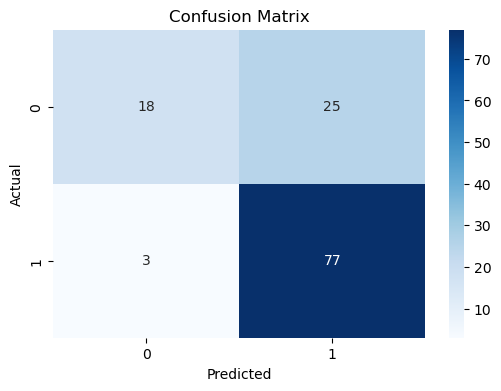

In [32]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Observation

The confusion matrix shows the number of correctly and incorrectly classified loan applications. A higher number of correct predictions indicates good model performance.

In [33]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
4,Credit_History,0.236743
0,ApplicantIncome,0.207041
2,LoanAmount,0.186974
1,CoapplicantIncome,0.116223
3,Loan_Amount_Term,0.056431
12,Property_Area_Semiurban,0.030435
6,Married_Yes,0.028514
13,Property_Area_Urban,0.023363
10,Education_Not Graduate,0.022994
5,Gender_Male,0.021656


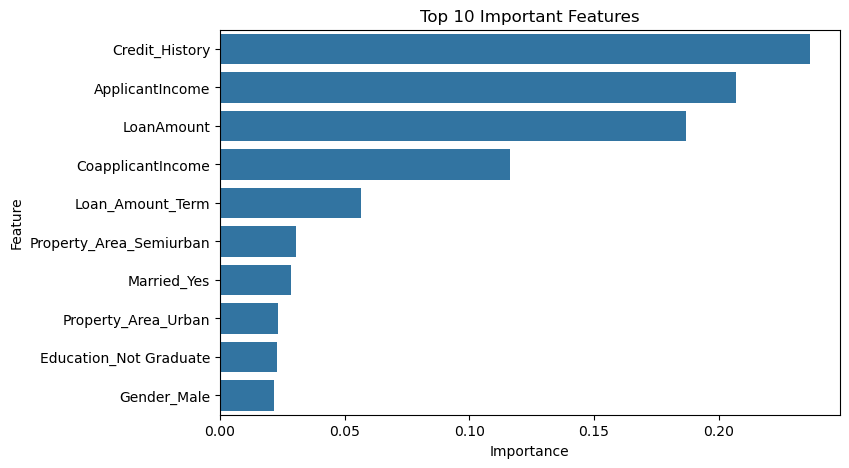

In [34]:
top_features = importance.head(10)

plt.figure(figsize=(8,5))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

### Observation

Credit History, Applicant Income, Loan Amount, and Property Area are among the most influential features affecting loan approval decisions.